# Dynamic Prompt
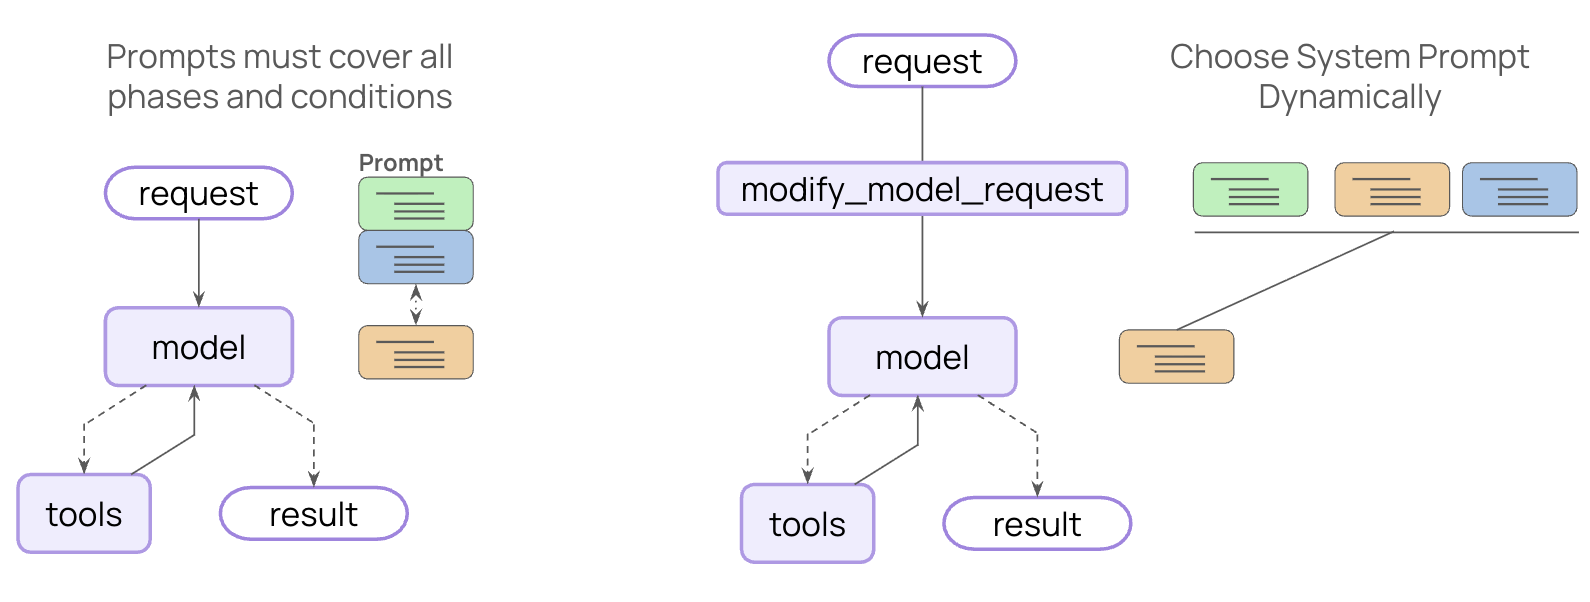

## Setup

Load and/or check for needed environmental variables

In [2]:
import os, httpx
from dotenv import load_dotenv

# Load .env using absolute path (override=True to ensure it always loads fresh)
load_dotenv("/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/.env", override=True)

CA_BUNDLE = "/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/ca-bundle.pem"
os.environ["SSL_CERT_FILE"] = CA_BUNDLE
os.environ["REQUESTS_CA_BUNDLE"] = CA_BUNDLE

# Create a custom httpx client with the CA bundle
http_client = httpx.Client(verify=CA_BUNDLE)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0, http_client=http_client)

In [4]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

In [5]:
from dataclasses import dataclass


@dataclass
class RuntimeContext:
    is_employee: bool
    db: SQLDatabase

In [6]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

In [7]:
SYSTEM_PROMPT_TEMPLATE = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows unless the user explicitly asks otherwise.
{table_limits}
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

## Build a Dynamic Prompt
Utilize runtime context and middleware to generate a dynamic prompt.

In [8]:
from langchain.agents.middleware.types import ModelRequest, dynamic_prompt


@dynamic_prompt
def dynamic_system_prompt(request: ModelRequest) -> str:
    if not request.runtime.context.is_employee:
        table_limits = "- Limit access to these tables: Album, Artist, Genre, Playlist, PlaylistTrack, Track."
    else:
        table_limits = ""

    return SYSTEM_PROMPT_TEMPLATE.format(table_limits=table_limits)

Include middleware in `create_agent`.

In [9]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=[execute_sql],
    middleware=[dynamic_system_prompt],
    context_schema=RuntimeContext,
)

In [10]:
question = "What is the most costly purchase by Frank Harris?"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    context=RuntimeContext(is_employee=False, db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the most costly purchase by Frank Harris?
================================== Ai Message ==================================

To find the most costly purchase by Frank Harris, I need to access the data in the database. 

Let's start by finding the purchases made by Frank Harris. 

I will assume that there is a table with customer information and another with purchase history.

Before I can write a query, I need to know the table and column names. Based on the provided table names, I will assume that Artist table has information about customers and Track table has information about purchases.

However, I don't see any table that directly relates to customers and their purchases. I will assume that Artist table has a column for customer name.

Let's try to find the purchases made by Frank Harris.
Tool Calls:
  execute_sql (n0e8xvn09)
 Call ID: n0e8xvn09
  Args:
    query: SELECT * FROM Artist WHERE Na

In [11]:
question = "What is the most costly purchase by Frank Harris?"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    context=RuntimeContext(is_employee=True, db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the most costly purchase by Frank Harris?
================================== Ai Message ==================================

To find the most costly purchase by Frank Harris, I will need to execute a SQL query. 

First, I assume that there is a table with Frank Harris's purchases. I will assume that the table name is 'purchases', and it has columns 'name', 'cost'. 

Here is my query:
Tool Calls:
  execute_sql (23419ya04)
 Call ID: 23419ya04
  Args:
    query: SELECT cost FROM purchases WHERE name = 'Frank Harris' ORDER BY cost DESC LIMIT 1
================================= Tool Message =================================
Name: execute_sql

Error: (sqlite3.OperationalError) no such table: purchases
[SQL: SELECT cost FROM purchases WHERE name = 'Frank Harris' ORDER BY cost DESC LIMIT 1]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
================================== Ai Message ==========